IMPORT

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RFM_PATH = PROCESSED_DIR / "rfm_clustered.csv"
BEHAVIOUR_PATH = PROCESSED_DIR / "rfm_refined_behavioural_clustered.csv"

print("Setup complete.")

Setup complete.


LOAD CLUSTER DATASET

In [19]:
rfm = pd.read_csv(RFM_PATH)
behaviour = pd.read_csv(BEHAVIOUR_PATH)

print("RFM shape:", rfm.shape)
print("Refined behavioural shape:", behaviour.shape)

display(rfm.head())
display(behaviour.head())

RFM shape: (4338, 7)
Refined behavioural shape: (4338, 12)


,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,Hierarchical_Cluster,GMM_Cluster
0,12346,326,1,77183.60,1,0,0
1,12347,2,7,4310.00,2,2,1
2,12348,75,4,1797.24,3,0,2
3,12349,19,1,1757.55,3,0,0
4,12350,310,1,334.40,1,1,0


,CustomerID,Recency,Frequency,Monetary,Customer_Lifetime_Days,Purchase_Velocity,Purchase_Interval_Std,Purchase_Regularity_Index,Invoice_Value_CV,KMeans_Cluster,Hierarchical_Cluster,GMM_Cluster
0,12346,326,1,77183.60,1,1.000000,0.000000,1.000000,0.000000,3,2,2
1,12347,2,7,4310.00,366,0.019126,18.478817,0.051338,0.553943,1,1,1
2,12348,75,4,1797.24,283,0.014134,70.149840,0.014055,0.670272,1,1,1
3,12349,19,1,1757.55,1,1.000000,0.000000,1.000000,0.000000,0,3,2
4,12350,310,1,334.40,1,1.000000,0.000000,1.000000,0.000000,3,2,2


EVALUATION FEATURES

In [20]:
rfm_features = [
    "Recency",
    "Frequency",
    "Monetary"
]

behaviour_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Customer_Lifetime_Days",
    "Purchase_Velocity",
    "Purchase_Interval_Std",
    "Purchase_Regularity_Index",
    "Invoice_Value_CV"
]

rfm_data = rfm[rfm_features]
behaviour_data = behaviour[behaviour_features]

print("RFM features:", rfm_data.columns.tolist())
print("Behavioural features:", behaviour_data.columns.tolist())

RFM features: ['Recency', 'Frequency', 'Monetary']
Behavioural features: ['Recency', 'Frequency', 'Monetary', 'Customer_Lifetime_Days', 'Purchase_Velocity', 'Purchase_Interval_Std', 'Purchase_Regularity_Index', 'Invoice_Value_CV']


OUTLIERS

In [21]:
def cap_outliers_iqr(data):
    capped = data.copy()

    for col in capped.columns:
        q1 = capped[col].quantile(0.25)
        q3 = capped[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        capped[col] = capped[col].clip(lower=lower, upper=upper)

    return capped


def preprocess_features(data):
    processed = cap_outliers_iqr(data)

    log_columns = [
        "Frequency",
        "Monetary",
        "Customer_Lifetime_Days",
        "Purchase_Velocity",
        "Purchase_Interval_Std"
    ]

    for col in log_columns:
        if col in processed.columns:
            processed[col] = np.log1p(processed[col])

    scaler = RobustScaler()
    scaled = scaler.fit_transform(processed)

    return scaled


rfm_scaled = preprocess_features(rfm_data)
behaviour_scaled = preprocess_features(behaviour_data)

print("Preprocessing completed.")
print("RFM scaled:", rfm_scaled.shape)
print("Behavioural scaled:", behaviour_scaled.shape)

Preprocessing completed.
RFM scaled: (4338, 3)
Behavioural scaled: (4338, 8)


EVALUATION FUNCTION

In [22]:
def evaluate_clustering(X, labels, dataset_name, model_name):
    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Silhouette Score": round(silhouette_score(X, labels), 4),
        "Davies-Bouldin Index": round(davies_bouldin_score(X, labels), 4),
        "Calinski-Harabasz Score": round(calinski_harabasz_score(X, labels), 2)
    }

EVALUATE ALL MODELS

In [23]:
results = []

models = {
    "K-Means": "KMeans_Cluster",
    "Hierarchical": "Hierarchical_Cluster",
    "GMM": "GMM_Cluster"
}

datasets = {
    "Traditional RFM": (rfm_scaled, rfm),
    "Refined Behavioural": (behaviour_scaled, behaviour)
}

for dataset_name, (X, df_model) in datasets.items():
    for model_name, cluster_col in models.items():
        results.append(
            evaluate_clustering(
                X=X,
                labels=df_model[cluster_col],
                dataset_name=dataset_name,
                model_name=model_name
            )
        )

evaluation_df = pd.DataFrame(results)

display(evaluation_df)

,Dataset,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,Traditional RFM,K-Means,0.3850,0.9094,4943.08
1,Traditional RFM,Hierarchical,0.3230,0.9026,3748.42
2,Traditional RFM,GMM,0.1842,1.5741,1919.84
3,Refined Behavioural,K-Means,0.4367,0.9358,3793.53
4,Refined Behavioural,Hierarchical,0.4049,1.0768,3391.38
5,Refined Behavioural,GMM,0.3018,2.1251,2343.00


RANK ALL MODEL 

In [24]:
ranking_df = evaluation_df.copy()

ranking_df["Silhouette Rank"] = ranking_df["Silhouette Score"].rank(
    ascending=False,
    method="min"
)

ranking_df["Davies-Bouldin Rank"] = ranking_df["Davies-Bouldin Index"].rank(
    ascending=True,
    method="min"
)

ranking_df["Calinski-Harabasz Rank"] = ranking_df["Calinski-Harabasz Score"].rank(
    ascending=False,
    method="min"
)

ranking_df["Average Rank"] = ranking_df[
    [
        "Silhouette Rank",
        "Davies-Bouldin Rank",
        "Calinski-Harabasz Rank"
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values("Average Rank").reset_index(drop=True)

display(ranking_df)

,Dataset,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Silhouette Rank,Davies-Bouldin Rank,Calinski-Harabasz Rank,Average Rank
0,Traditional RFM,K-Means,0.3850,0.9094,4943.08,3.0,2.0,1.0,2.000000
1,Refined Behavioural,K-Means,0.4367,0.9358,3793.53,1.0,3.0,2.0,2.000000
2,Traditional RFM,Hierarchical,0.3230,0.9026,3748.42,4.0,1.0,3.0,2.666667
3,Refined Behavioural,Hierarchical,0.4049,1.0768,3391.38,2.0,4.0,4.0,3.333333
4,Refined Behavioural,GMM,0.3018,2.1251,2343.00,5.0,6.0,5.0,5.333333
5,Traditional RFM,GMM,0.1842,1.5741,1919.84,6.0,5.0,6.0,5.666667


SAVE EVALUATION

In [25]:
evaluation_df.to_csv(
    TABLES_DIR / "final_clustering_evaluation_metrics.csv",
    index=False
)

ranking_df.to_csv(
    TABLES_DIR / "final_model_ranking.csv",
    index=False
)

print("Saved:")
print(TABLES_DIR / "final_clustering_evaluation_metrics.csv")
print(TABLES_DIR / "final_model_ranking.csv")

Saved:
..\outputs\tables\final_clustering_evaluation_metrics.csv
..\outputs\tables\final_model_ranking.csv


BEST MODEL

In [26]:
best_model = ranking_df.iloc[0]

print("="*80)
print("BEST OVERALL MODEL")
print("="*80)

print("Dataset:", best_model["Dataset"])
print("Algorithm:", best_model["Model"])
print("Silhouette Score:", best_model["Silhouette Score"])
print("Davies-Bouldin Index:", best_model["Davies-Bouldin Index"])
print("Calinski-Harabasz Score:", best_model["Calinski-Harabasz Score"])
print("Average Rank:", round(best_model["Average Rank"], 2))

print("="*80)

BEST OVERALL MODEL
Dataset: Traditional RFM
Algorithm: K-Means
Silhouette Score: 0.385
Davies-Bouldin Index: 0.9094
Calinski-Harabasz Score: 4943.08
Average Rank: 2.0


SILHOUETTE COMPARISON CHART

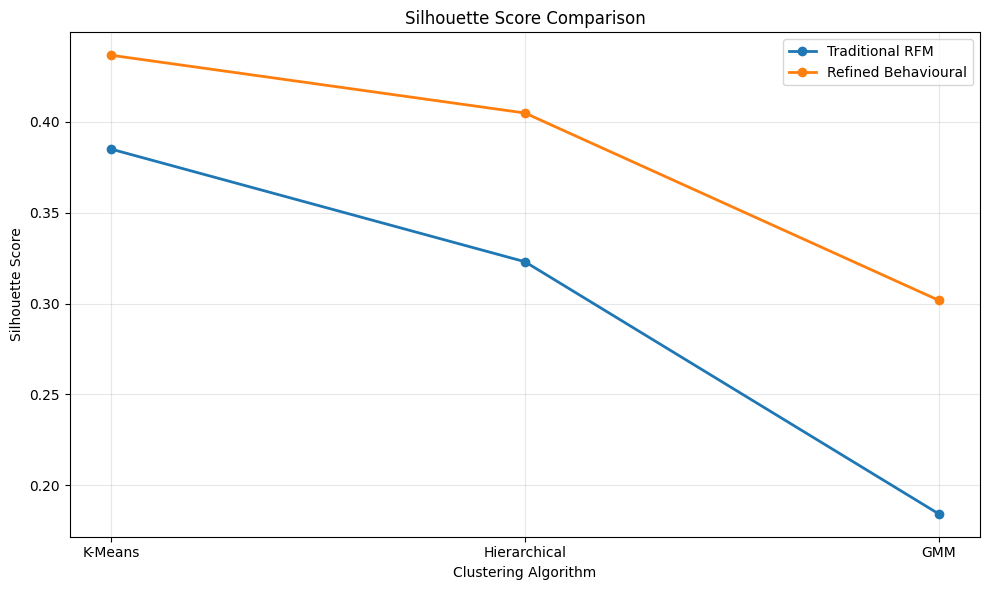

In [27]:
plt.figure(figsize=(10, 6))

for dataset in evaluation_df["Dataset"].unique():
    subset = evaluation_df[evaluation_df["Dataset"] == dataset]

    plt.plot(
        subset["Model"],
        subset["Silhouette Score"],
        marker="o",
        linewidth=2,
        label=dataset
    )

plt.title("Silhouette Score Comparison")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_silhouette_comparison.png",
    dpi=300
)

plt.show()

DAVIES BOULDIN COMPARISON CHART

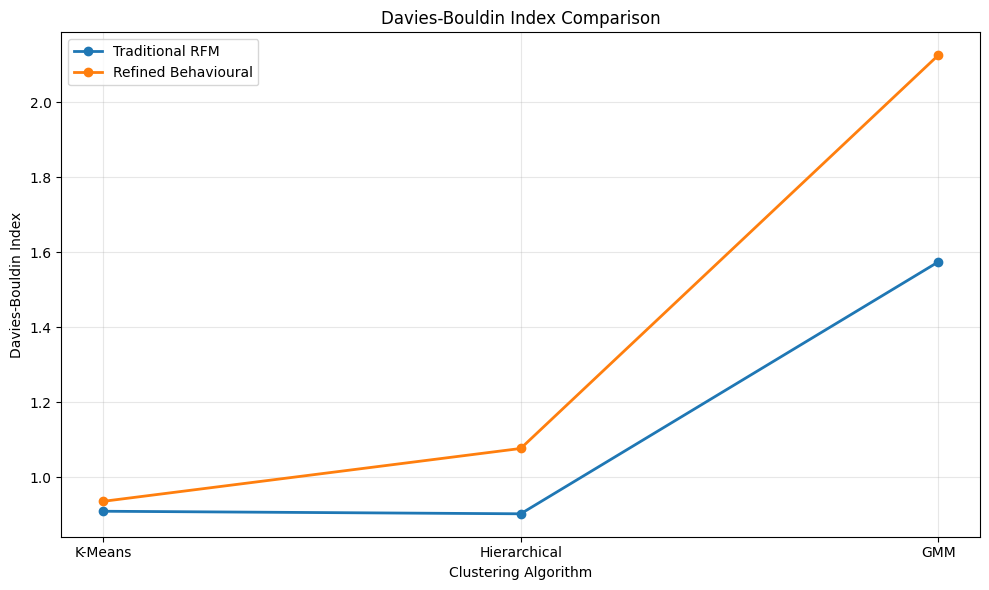

In [28]:
plt.figure(figsize=(10, 6))

for dataset in evaluation_df["Dataset"].unique():
    subset = evaluation_df[evaluation_df["Dataset"] == dataset]

    plt.plot(
        subset["Model"],
        subset["Davies-Bouldin Index"],
        marker="o",
        linewidth=2,
        label=dataset
    )

plt.title("Davies-Bouldin Index Comparison")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Davies-Bouldin Index")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_davies_bouldin_comparison.png",
    dpi=300
)

plt.show()

CALINSKI HARABASZ COMPARISON 

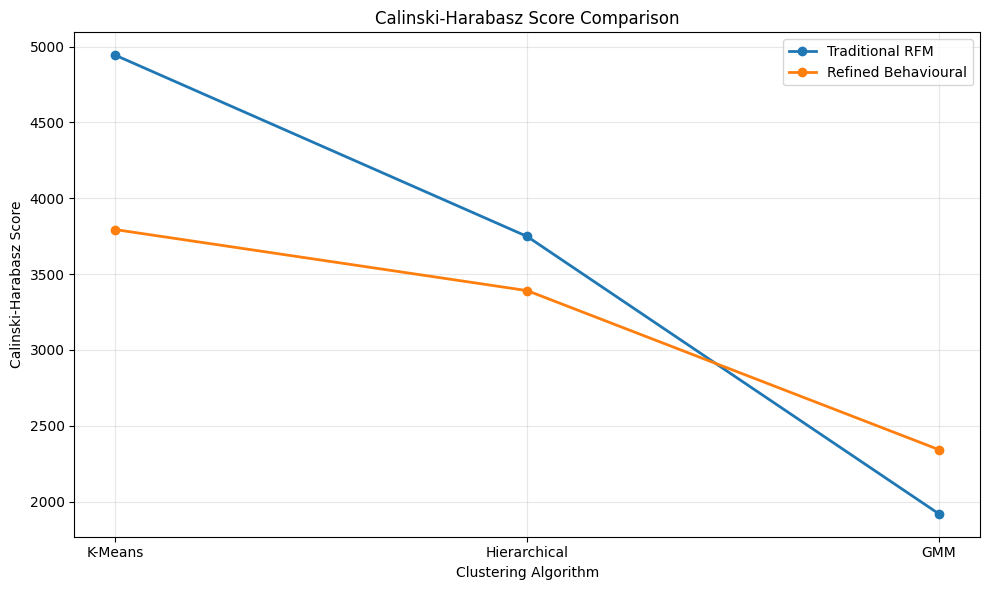

In [29]:
plt.figure(figsize=(10, 6))

for dataset in evaluation_df["Dataset"].unique():
    subset = evaluation_df[evaluation_df["Dataset"] == dataset]

    plt.plot(
        subset["Model"],
        subset["Calinski-Harabasz Score"],
        marker="o",
        linewidth=2,
        label=dataset
    )

plt.title("Calinski-Harabasz Score Comparison")
plt.xlabel("Clustering Algorithm")
plt.ylabel("Calinski-Harabasz Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "final_calinski_harabasz_comparison.png",
    dpi=300
)

plt.show()

RESEARCH CONCLUSION

In [30]:
rfm_kmeans = evaluation_df[
    (evaluation_df["Dataset"] == "Traditional RFM") &
    (evaluation_df["Model"] == "K-Means")
].iloc[0]

behaviour_kmeans = evaluation_df[
    (evaluation_df["Dataset"] == "Refined Behavioural") &
    (evaluation_df["Model"] == "K-Means")
].iloc[0]

silhouette_improvement = (
    (behaviour_kmeans["Silhouette Score"] - rfm_kmeans["Silhouette Score"])
    / rfm_kmeans["Silhouette Score"]
) * 100

print("="*80)
print("RESEARCH CONCLUSION")
print("="*80)

print(f"Traditional RFM K-Means Silhouette      : {rfm_kmeans['Silhouette Score']}")
print(f"Refined Behavioural K-Means Silhouette : {behaviour_kmeans['Silhouette Score']}")

print()
print(f"Silhouette improvement of refined behavioural model over RFM: {silhouette_improvement:.2f}%")

print()
print("Interpretation:")
print("The refined behavioural volatility feature set achieved stronger cluster separation")
print("than traditional RFM under K-Means, indicating that carefully selected behavioural")
print("features can improve unsupervised customer segmentation quality.")

print()
print("The refined behavioural model also provides richer interpretability because it includes")
print("customer lifetime, purchase velocity, purchase interval variability, regularity,")
print("and invoice value variability in addition to traditional RFM.")

print("="*80)

RESEARCH CONCLUSION
Traditional RFM K-Means Silhouette      : 0.385
Refined Behavioural K-Means Silhouette : 0.4367

Silhouette improvement of refined behavioural model over RFM: 13.43%

Interpretation:
The refined behavioural volatility feature set achieved stronger cluster separation
than traditional RFM under K-Means, indicating that carefully selected behavioural
features can improve unsupervised customer segmentation quality.

The refined behavioural model also provides richer interpretability because it includes
customer lifetime, purchase velocity, purchase interval variability, regularity,
and invoice value variability in addition to traditional RFM.


EVALUATION 

In [31]:
print("="*80)
print("06_evaluation.ipynb COMPLETED SUCCESSFULLY")
print("="*80)

print("Models evaluated:")
print("✓ Traditional RFM - K-Means")
print("✓ Traditional RFM - Hierarchical")
print("✓ Traditional RFM - GMM")
print("✓ Refined Behavioural - K-Means")
print("✓ Refined Behavioural - Hierarchical")
print("✓ Refined Behavioural - GMM")

print("\nMetrics used:")
print("✓ Silhouette Score")
print("✓ Davies-Bouldin Index")
print("✓ Calinski-Harabasz Score")

print("\nFiles saved:")
print("✓ final_clustering_evaluation_metrics.csv")
print("✓ final_model_ranking.csv")
print("✓ final_silhouette_comparison.png")
print("✓ final_davies_bouldin_comparison.png")
print("✓ final_calinski_harabasz_comparison.png")

print("="*80)

06_evaluation.ipynb COMPLETED SUCCESSFULLY
Models evaluated:
✓ Traditional RFM - K-Means
✓ Traditional RFM - Hierarchical
✓ Traditional RFM - GMM
✓ Refined Behavioural - K-Means
✓ Refined Behavioural - Hierarchical
✓ Refined Behavioural - GMM

Metrics used:
✓ Silhouette Score
✓ Davies-Bouldin Index
✓ Calinski-Harabasz Score

Files saved:
✓ final_clustering_evaluation_metrics.csv
✓ final_model_ranking.csv
✓ final_silhouette_comparison.png
✓ final_davies_bouldin_comparison.png
✓ final_calinski_harabasz_comparison.png
